# mechanism_viewer examples

## Use a matrix to detect missing patterns

This notebook contains examples in how to use functions belonging to `viewer_matrix.py`, namely `visualize_column_dependencies()` and `missing_rate_matrix()`.

> Note: These visualizations are exploratory and should be used together with additional tests before concluding the missing-data mechanism.

### 1. Generate synthetic dataset with missing values

For this example, one complete column and multiple missing columns are used so both matrix plots are informative.

In [1]:
from mechanism_viewer import generate_dataset_with_missing_data, ColType

data = generate_dataset_with_missing_data(200, [ColType.DISCRETE, ColType.CONTINUOUS, ColType.CONTINUOUS,
                                                ColType.BINARY], 1, ["MCAR", "MAR", "MCAR"], [0.4, 0.2, 0.4])


display(data.head(10))

,Col1,Col2,Col3,Col4
0,5,NaN,0.197566,<NA>
1,4,0.965015,0.449228,<NA>
2,4,-0.480132,-1.076661,1
3,5,NaN,0.668408,1
4,5,0.367102,-1.089593,0
5,3,NaN,1.631126,<NA>
6,5,-0.131038,-0.771628,1
7,4,-2.035240,0.296628,<NA>
8,6,NaN,1.005143,<NA>
9,7,1.080069,NaN,1


### 2. Visualize row-level dependency matrix

The function `visualize_column_dependencies()` focuses on rows that contain at least one missing value.
Complete columns are shown in green shades (value intensity), and missing columns are shown in red (missingness pattern). The patterns shown in red enable the user to suggest possible missing data mechanism of columns. For example, if most missing values of a column do not appear scattered, then the plot may suggest the column having a non-MCAR mechanism.

The function has an option to sort the dataset using the complete columns, so that it is easier to perceive a missingness pattern. Of course, changing the order of the rows may alter the pattern that was previuosly formed in the original dataset. To sort with the complete columns, `sort_by_complete` must be set to `True`. The default value is `False`.

Moreover, the function returns `(figure, axis)` and can display directly with `display_plot=True`.

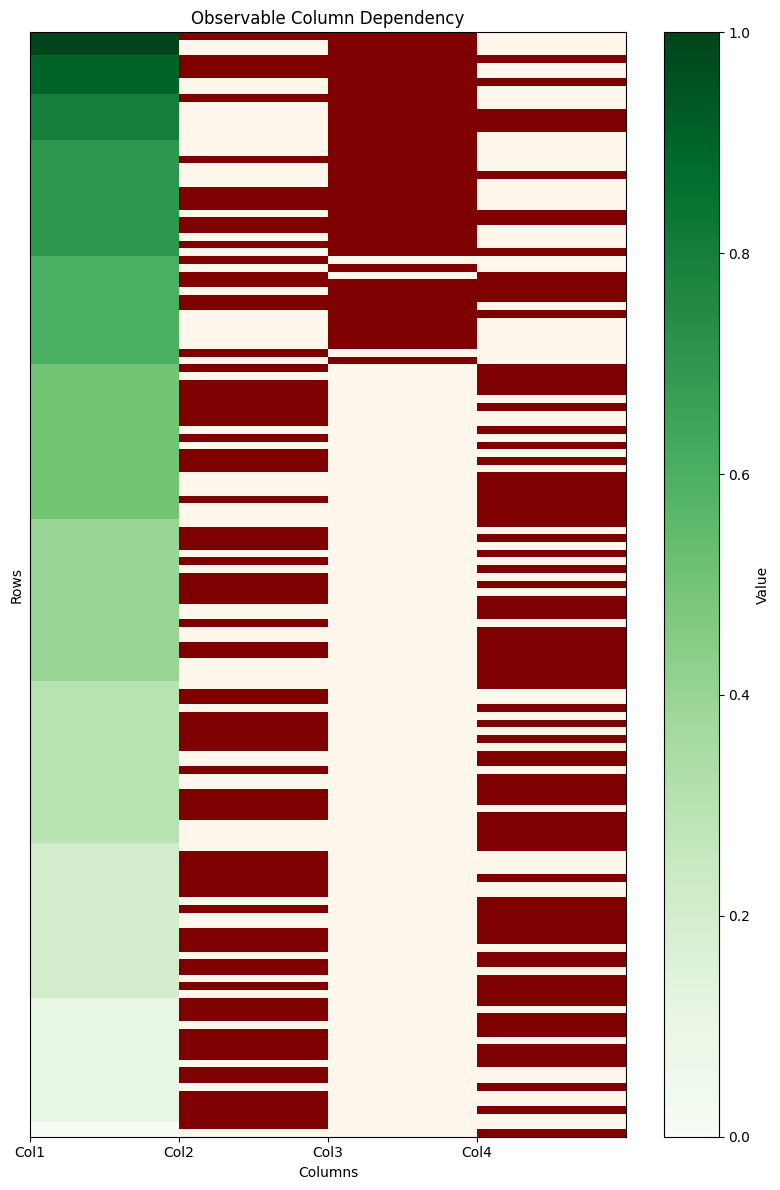

In [2]:
from mechanism_viewer import visualize_column_dependencies

fig_dep_matrix, ax_dep_matrix = visualize_column_dependencies(data, sort_by_complete=True, display_plot=True)

### 3. Visualize grouped missing-rate matrix

The function `missing_rate_matrix()` groups by one observed column (`column_name`) and shows how missing rates of the other columns vary across that column's unique values. In this example, `Col1` is used as the observed column.

In this function, it is possible to sort the unique values of the observed column using `sort_by_column=True`, which is the default value.

The function also returns a `(figure, axis)` tuple, and has the option of setting `display_plot=True` to display the plot in the notebook.

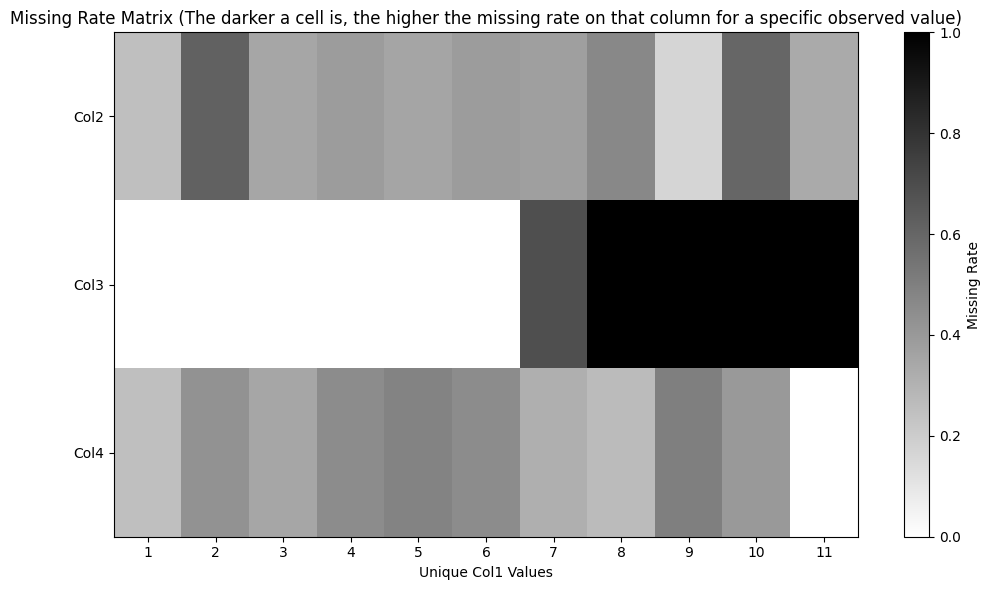

In [3]:
from mechanism_viewer import missing_rate_matrix

fig_miss_matrix, ax_miss_matrix = missing_rate_matrix(data, column_name="Col1", sort_by_column=True, display_plot=True)

For example, because the function returns `figure` and `axis`, the titles and labels of the plot can be customized.

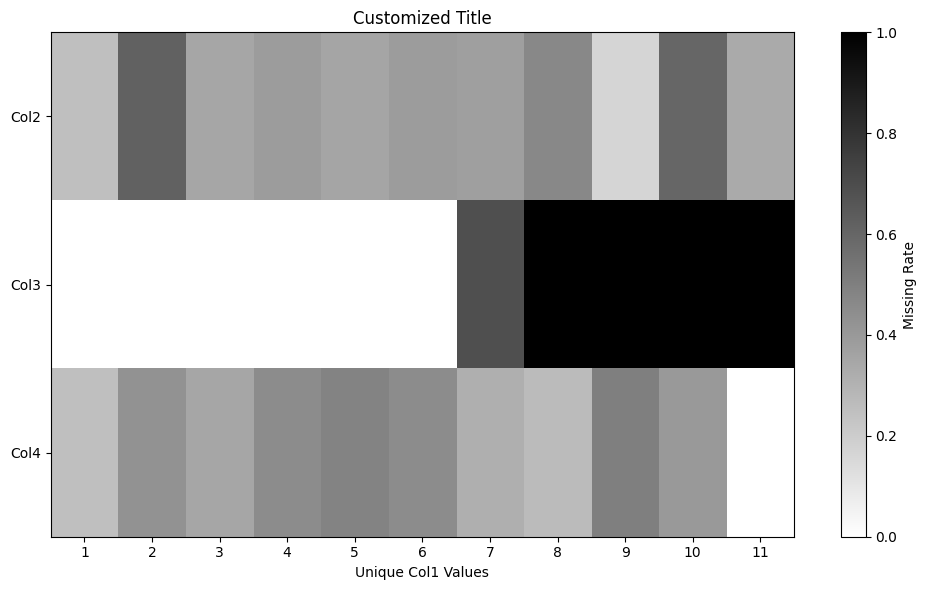

In [5]:
ax_miss_matrix.set_title("Customized Title")
fig_miss_matrix